In [1]:
from src.inference import load_model

# Load model from disk
model = load_model(model_path="mnist_cnn.pt", device="cpu")

In [2]:
# Load MNIST dataset
from src.data.dataset import get_data_loaders
_, test_loader = get_data_loaders(data_dir="data")

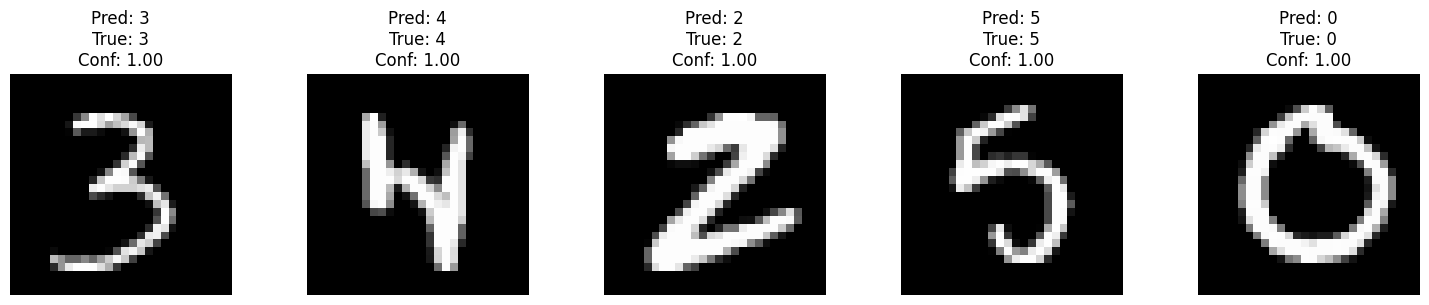

In [3]:
# Select random images and perform inference
import random
import matplotlib.pyplot as plt
from src.inference import predict_digit
import torch

# Set number of samples
num_samples = 5

# Select random samples from test dataset
dataset = test_loader.dataset
indices = random.sample(range(len(dataset)), num_samples)
samples = [dataset[i] for i in indices]

# Create figure for displaying results
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

# Perform inference on each sample
for i, (image, true_label) in enumerate(samples):
    # Display image
    axes[i].imshow(image.squeeze(), cmap='gray')

    # Run inference
    predicted_digit, probabilities = predict_digit(model, image)

    # Display results
    confidence = probabilities[predicted_digit]
    title = f"Pred: {predicted_digit}\nTrue: {true_label}\nConf: {confidence:.2f}"
    axes[i].set_title(title)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Display detailed probability distributions
for i, (image, true_label) in enumerate(samples):
    predicted_digit, probabilities = predict_digit(model, image)
    print(f"Sample {i+1} - True digit: {true_label}, Predicted: {predicted_digit}")
    print(f"Probability distribution: {[f'{p:.4f}' for p in probabilities]}")
    print()

Sample 1 - True digit: 3, Predicted: 3
Probability distribution: ['0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']

Sample 2 - True digit: 4, Predicted: 4
Probability distribution: ['0.0000', '0.0000', '0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']

Sample 3 - True digit: 2, Predicted: 2
Probability distribution: ['0.0000', '0.0000', '1.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']

Sample 4 - True digit: 5, Predicted: 5
Probability distribution: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.9999', '0.0000', '0.0000', '0.0000', '0.0000']

Sample 5 - True digit: 0, Predicted: 0
Probability distribution: ['1.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000', '0.0000']

